In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
print("Median:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].median())

print("\nMode:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].mode().iloc[0])

print("\nStandard Deviation:")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].std())

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

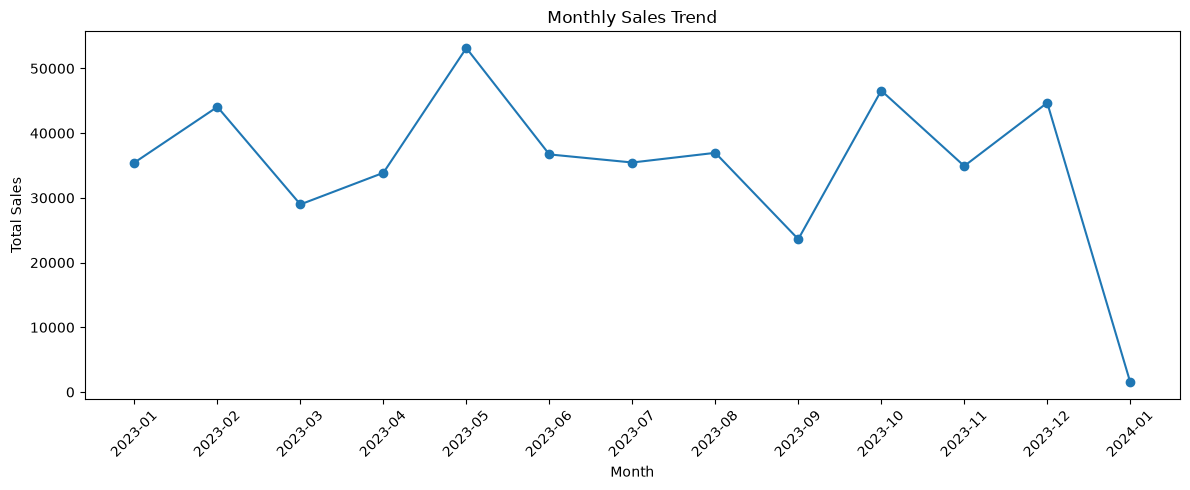

In [10]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation – Monthly Sales Trend

- Sales varied across different months.
- May 2023 recorded the highest monthly sales among the full months in the dataset.
- September 2023 recorded relatively low sales.
- January 2024 shows much lower sales, which may be because the dataset contains only a partial month.

In [11]:
quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

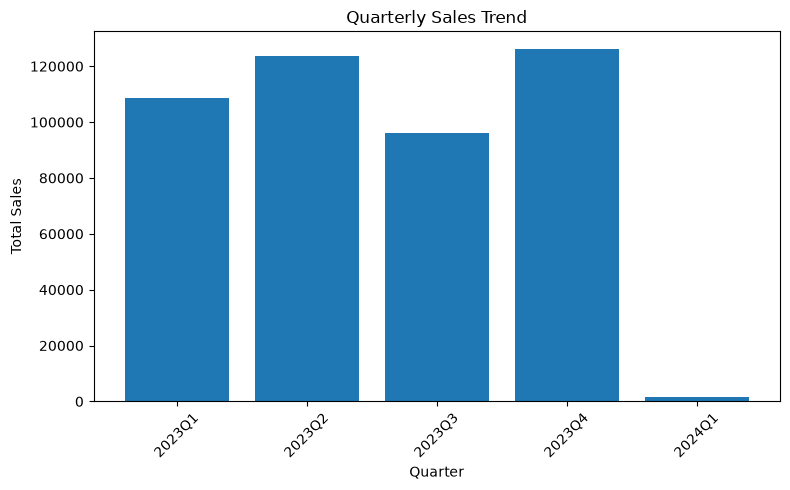

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(quarterly_sales.index.astype(str), quarterly_sales.values)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

- Q4 2023 recorded the highest quarterly sales at 126,190.
- Q2 2023 recorded the second-highest sales at 123,735.
- Q3 2023 had the lowest sales among the complete quarters of 2023, at 96,045.
- Q1 2024 shows very low sales because the dataset contains only a partial January 2024 period.


In [13]:
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-64"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_groups = df["Age Group"].value_counts().sort_index()

age_groups

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64

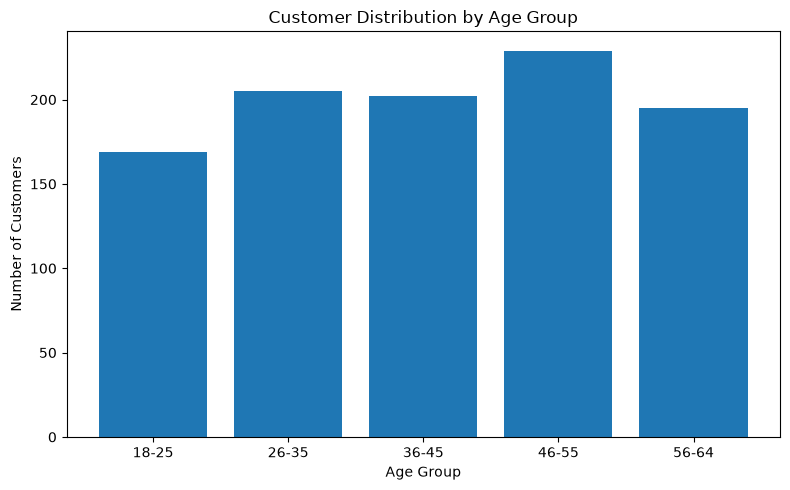

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(age_groups.index, age_groups.values)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation – Customer Distribution by Age Group

- The 46-55 age group has the highest number of customers, with 229 customers.
- The 18-25 age group has the lowest number of customers, with 169 customers.
- The remaining age groups have a relatively balanced customer distribution.
- Customers are present across all five age groups in the dataset.

In [15]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

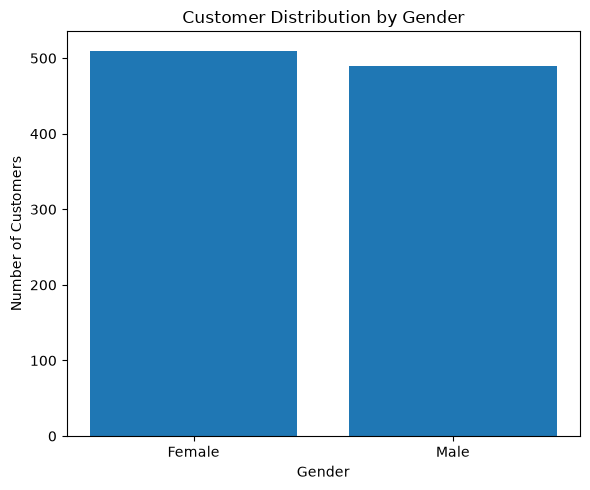

In [16]:
plt.figure(figsize=(6, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation – Customer Distribution by Gender

- Female customers account for 510 transactions.
- Male customers account for 490 transactions.
- The distribution is nearly balanced between female and male customers.
- Female transactions are slightly higher than male transactions in this dataset.

In [17]:
category_quantity = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

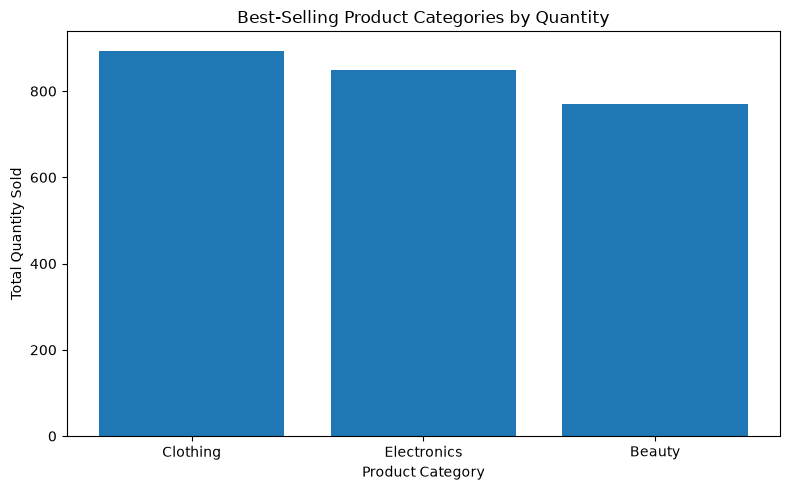

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(category_quantity.index, category_quantity.values)

plt.title("Best-Selling Product Categories by Quantity")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.tight_layout()
plt.show()

### Observation – Best-Selling Product Categories

- Clothing has the highest quantity sold, with 894 units.
- Electronics follows with 849 units sold.
- Beauty has the lowest quantity sold among the three categories, with 771 units.
- Clothing is the leading category by quantity in this dataset.

In [19]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

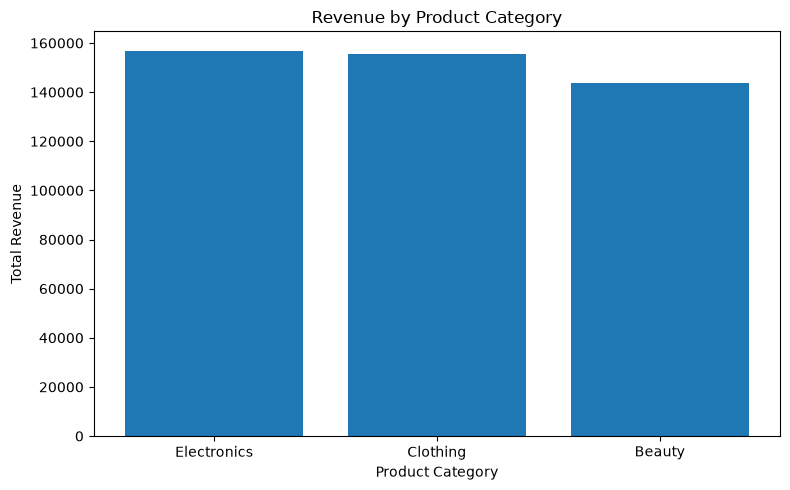

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(category_revenue.index, category_revenue.values)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Observation – Revenue by Product Category

- Electronics generated the highest revenue of 156,905.
- Clothing generated 155,580 in revenue, which is very close to Electronics.
- Beauty generated the lowest revenue of 143,515.
- Electronics generated the highest revenue even though Clothing had the highest quantity sold.

In [21]:
correlation = df[[
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


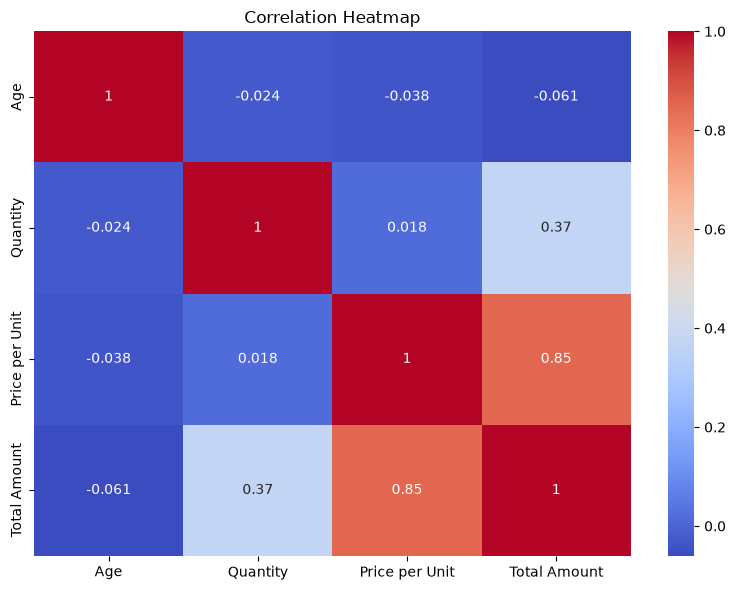

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

- Price per Unit and Total Amount show a strong positive correlation of 0.852.
- Quantity and Total Amount show a moderate positive correlation of 0.374.
- Age and Total Amount have a very weak negative correlation of -0.061.
- Age has very little linear relationship with the other numerical variables in this dataset.

In [ ]:
correlation = df[[
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


In [23]:
avg_sales_age = df.groupby("Age Group", observed=True)["Total Amount"].mean()

avg_sales_age

Age Group
18-25    500.295858
26-35    480.390244
36-45    454.801980
46-55    439.694323
56-64    412.358974
Name: Total Amount, dtype: float64

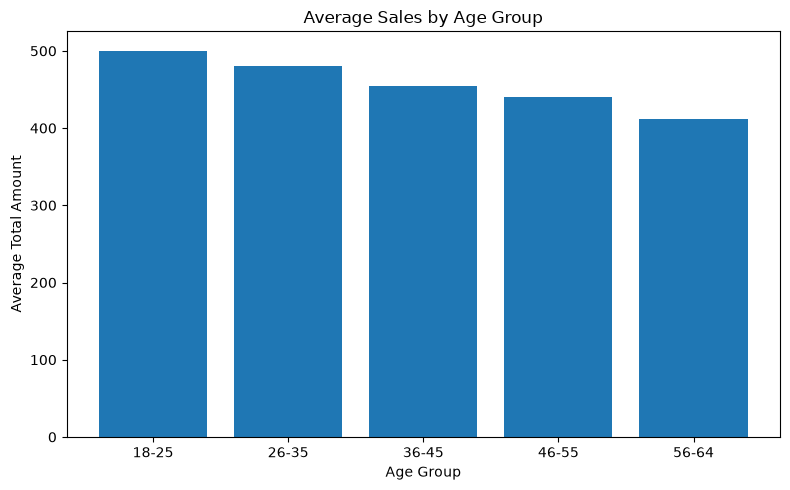

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(avg_sales_age.index, avg_sales_age.values)

plt.title("Average Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")

plt.tight_layout()
plt.show()

### Observation – Average Sales by Age Group

- The 18-25 age group has the highest average transaction amount of approximately 500.30.
- The average transaction amount decreases across the age groups.
- The 56-64 age group has the lowest average transaction amount of approximately 412.36.
- This indicates that younger customers had higher average transaction amounts in this dataset.

## Conclusion

The Exploratory Data Analysis of the Retail Sales Dataset provided useful insights into customer behavior, sales trends, and product category performance. Sales varied across months and quarters, while the customer distribution was relatively balanced across genders and age groups. Electronics generated the highest revenue, whereas Clothing had the highest quantity sold. The correlation analysis showed a strong positive relationship between Price per Unit and Total Amount.

### Actionable Business Recommendations

1. **Focus on high-revenue categories:**  
   Prioritize Electronics and Clothing through suitable promotions, inventory planning, and product placement because they generated the highest revenue.

2. **Target high-value customer segments:**  
   Use age-group analysis to design targeted marketing campaigns, especially for younger customers who showed higher average transaction amounts in this dataset.

3. **Plan inventory and promotions using sales trends:**  
   Monitor monthly and quarterly sales patterns to prepare inventory and promotional campaigns ahead of higher-sales periods and improve performance during lower-sales periods.